# Sustainable Urban Logistics Optimization — GreenCity Logistics
### Integrated Mixed-Integer Programming Decision System

**Course:** ISBA 2405 — Prescriptive Analytics\
**Team:** Team 5 \
**Members:** Tianqi Wang, Wenni Xu, Xiao Yue Lin, Jiaru Li\
**Date:** June 1, 2026

---

## 1 · Problem Definition and Decision Questions

### Main Problem

GreenCity Logistics must design a sustainable last-mile delivery network for an urban area. The company needs to decide which candidate micro-fulfillment centers to open, how to assign customer demand zones to those facilities, which vehicle types to use on each facility-zone route, and how many delivery trips are required.

The main decision problem is:

> **How should GreenCity Logistics configure its micro-fulfillment center network and vehicle assignments to serve all demand zones at minimum cost while satisfying facility capacity, vehicle capacity, delivery-time, environmental, and Client C103 service requirements?**

We answer the problem using an integrated mixed-integer programming model. The model balances three objectives: total cost, emissions, and service quality.

### Decision Questions

| Question | How it is answered |
|---|---|
| 1. Which micro-fulfillment centers should GreenCity open? | The binary facility decision variable `y[i]` and Report 1: Selected Facility Report. |
| 2. Which facility should serve each demand zone? | Assignment variable `z[i,j]`, flow variable `x[i,j]`, and Report 2: Demand Allocation Report. |
| 3. Which vehicle type should be used on each route? | Vehicle assignment variable `w[i,j,v]`, trip variable `r[i,j,v]`, and Report 3: Vehicle Assignment Report. |
| 4. Can the network satisfy capacity, range, time-window, low-emission-zone, and emission-cap constraints? | The model constraints and validation checks in Section 12. |
| 5. Can GreenCity satisfy Client C103’s requirements? | The C103 constraints: electric vehicles in LEZ zones, 2-hour delivery feasibility, complete zone service, and max 6 C103 stops per facility. |
| 6. What are the trade-offs between cost, emissions, and service quality? | The multi-objective trade-off analysis in Report 8. |
| 7. How sensitive is the recommendation to demand growth and stricter environmental policy? | Sensitivity analysis in Report 9. |
| 8. What final network recommendation should GreenCity implement? | Managerial recommendation in Section 16. |

### Scope

The model focuses on strategic and tactical last-mile delivery decisions: facility selection, demand allocation, vehicle assignment, trip counts, cost, emissions, and service feasibility. It does not model full route sequencing or exact vehicle arrival times.

### Core Objectives

1. **Minimize total system cost**: facility cost, fleet cost, transportation cost, tolls, and congestion charges.
2. **Minimize environmental impact**: delivery-related CO2 emissions and low-emission-zone compliance.
3. **Maximize service quality**: faster and more reliable service, especially for priority demand zones.

## 2 · Gurobi Academic WLS setup

Each team member uses **their own** WLS Academic license (do not share credentials, do not
commit them to a public repo). Get an academic account with your `@scu.edu` email, connect to
the SCU network/VPN, request a **WLS Academic** license, download `gurobi.lic`, and copy the three
fields below. We open one `Env` and reuse it for every solve in the notebook.

In [ ]:
!pip install gurobipy>=10 -q

import gurobipy as gp
from gurobipy import GRB

# === Paste YOUR personal WLS credentials (from gurobi.lic) ===
params = {
    "WLSACCESSID": "paste-your-access-id-here",     # String
    "WLSSECRET": "paste-your-secret-here",          # String
    "LICENSEID": 12127,                              # Integer (replace with yours)
}

# One shared environment reused across all solves (payoff table + scenarios).
ENV = gp.Env(params=params)
print("Gurobi version:", gp.gurobi.version())
print("Environment ready.")


## 3 · Import libraries

In [2]:
import pandas as pd
import numpy as np
import math
import os
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
np.set_printoptions(suppress=True)
print("Libraries imported.")

Libraries imported.


## 4 · Load & Clean Data Files

In [3]:
# Load files
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/Shareddrives/Prescriptive Analytics Capstone Project/"

loc_df  = pd.read_csv(BASE_PATH + 'location_data.csv')
dem_df  = pd.read_csv(BASE_PATH + 'demand_data.csv')
veh_df  = pd.read_csv(BASE_PATH + 'vehicle_data.csv')
dist_df = pd.read_csv(BASE_PATH + 'distance_matrix_SAMPLE_50routes.csv')
env_df  = pd.read_csv(BASE_PATH + 'emission_constraints.csv')

# Standardize columns & strings
def clean_columns(df):
    df = df.copy()
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(' ', '_').str.replace('-', '_'))
    return df

def clean_strings(df):
    df = df.copy()
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip().replace('nan', np.nan)
    return df

loc_df  = clean_strings(clean_columns(loc_df))
dem_df  = clean_strings(clean_columns(dem_df))
veh_df  = clean_strings(clean_columns(veh_df))
dist_df = clean_strings(clean_columns(dist_df))
env_df  = clean_strings(clean_columns(env_df))

# Ensure ID columns are clean strings
loc_df['location_id']  = loc_df['location_id'].astype(str).str.strip()
dem_df['zone_id']      = dem_df['zone_id'].astype(str).str.strip()
env_df['zone_id']      = env_df['zone_id'].astype(str).str.strip()
dist_df['origin']      = dist_df['origin'].astype(str).str.strip()
dist_df['destination'] = dist_df['destination'].astype(str).str.strip()

for name, df in [('locations', loc_df), ('demand', dem_df), ('vehicles', veh_df),
                 ('distance(sample)', dist_df), ('emissions', env_df)]:
    print(f"{name:18s}: {df.shape}")

Mounted at /content/drive
locations         : (25, 12)
demand            : (30, 11)
vehicles          : (10, 12)
distance(sample)  : (50, 8)
emissions         : (30, 10)


## 5 · Complete the 750-route distance matrix

The optimizer requires a complete distance matrix for all facility-zone combinations, totaling 25 × 30 = 750 routes, but the original sample only provides 50 observed routes.

To complete the matrix, we use the professor-provided generation logic to build the full facility-zone grid and calculate haversine distance from facility and zone latitude/longitude coordinates. Travel time and route attributes, including congestion, emission factor, toll cost, and reliability, are then estimated using consistent rule-based assumptions derived from distance. This completed 750-route matrix provides the route-level inputs needed for the downstream optimization model.

In [4]:
import math
import csv

# Locations (25)
locations = [
    {'id':'L001','lat':40.7128,'lng':-73.9960},{'id':'L002','lat':40.7148,'lng':-73.9980},
    {'id':'L003','lat':40.7165,'lng':-73.9945},{'id':'L004','lat':40.7070,'lng':-73.9885},
    {'id':'L005','lat':40.7090,'lng':-73.9850},{'id':'L006','lat':40.7195,'lng':-73.9828},
    {'id':'L007','lat':40.7210,'lng':-73.9980},{'id':'L008','lat':40.7250,'lng':-73.9945},
    {'id':'L009','lat':40.7180,'lng':-74.0000},{'id':'L010','lat':40.7090,'lng':-74.0015},
    {'id':'L011','lat':40.7040,'lng':-73.9980},{'id':'L012','lat':40.7065,'lng':-74.0000},
    {'id':'L013','lat':40.7300,'lng':-73.9848},{'id':'L014','lat':40.7340,'lng':-73.9878},
    {'id':'L015','lat':40.7280,'lng':-73.9820},{'id':'L016','lat':40.7200,'lng':-73.9757},
    {'id':'L017','lat':40.7150,'lng':-74.0000},{'id':'L018','lat':40.7020,'lng':-73.9798},
    {'id':'L019','lat':40.7380,'lng':-73.9900},{'id':'L020','lat':40.7220,'lng':-74.0005},
    {'id':'L021','lat':40.7110,'lng':-73.9777},{'id':'L022','lat':40.7330,'lng':-73.9950},
    {'id':'L023','lat':40.7030,'lng':-74.0040},{'id':'L024','lat':40.7260,'lng':-73.9995},
    {'id':'L025','lat':40.7170,'lng':-73.9888}
]

# Zones (30)
zones = [
    {'id':'Z001','lat':40.7129,'lng':-73.9958},{'id':'Z002','lat':40.7145,'lng':-73.9980},
    {'id':'Z003','lat':40.7168,'lng':-73.9945},{'id':'Z004','lat':40.7072,'lng':-73.9882},
    {'id':'Z005','lat':40.7092,'lng':-73.9848},{'id':'Z006','lat':40.7198,'lng':-73.9825},
    {'id':'Z007','lat':40.7213,'lng':-73.9980},{'id':'Z008','lat':40.7252,'lng':-73.9945},
    {'id':'Z009','lat':40.7183,'lng':-74.0000},{'id':'Z010','lat':40.7093,'lng':-74.0015},
    {'id':'Z011','lat':40.7042,'lng':-73.9980},{'id':'Z012','lat':40.7067,'lng':-74.0000},
    {'id':'Z013','lat':40.7303,'lng':-73.9848},{'id':'Z014','lat':40.7342,'lng':-73.9878},
    {'id':'Z015','lat':40.7283,'lng':-73.9818},{'id':'Z016','lat':40.7202,'lng':-73.9757},
    {'id':'Z017','lat':40.7153,'lng':-74.0000},{'id':'Z018','lat':40.7022,'lng':-73.9798},
    {'id':'Z019','lat':40.7383,'lng':-73.9900},{'id':'Z020','lat':40.7223,'lng':-74.0005},
    {'id':'Z021','lat':40.7113,'lng':-73.9777},{'id':'Z022','lat':40.7333,'lng':-73.9950},
    {'id':'Z023','lat':40.7033,'lng':-74.0000},{'id':'Z024','lat':40.7263,'lng':-73.9995},
    {'id':'Z025','lat':40.7172,'lng':-73.9888},{'id':'Z026','lat':40.7192,'lng':-73.9965},
    {'id':'Z027','lat':40.7087,'lng':-73.9835},{'id':'Z028','lat':40.7242,'lng':-74.0025},
    {'id':'Z029','lat':40.7048,'lng':-73.9983},{'id':'Z030','lat':40.7316,'lng':-73.9895}
]

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dLat = math.radians(lat2 - lat1)
    dLon = math.radians(lon2 - lon1)
    a = math.sin(dLat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dLon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c

# Generate distance matrix
output_matrix_path = BASE_PATH + 'distance_matrix_COMPLETE_750routes.csv'
with open(output_matrix_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['origin','destination','distance_km','travel_time_mins','congestion_factor','emission_factor','toll_cost','time_reliability'])

    for origin in locations:
        for dest in zones:
            dist = haversine(origin['lat'], origin['lng'], dest['lat'], dest['lng'])
            cong = 1.1 if dist < 0.5 else 1.2 if dist < 1.5 else 1.3 if dist < 3.0 else 1.4
            #time = round((dist / 25) * 60 * cong)
            time = max(1, round((dist / 25) * 60 * cong))
            emis = 1.0 if dist < 1 else 1.1 if dist < 2 else 1.2 if dist < 4 else 1.3
            toll = 2.5 if dist > 4 else 0.0
            rel = max(0.80, round(0.98 - (dist * 0.01) - ((cong - 1.0) * 0.1), 2))

            writer.writerow([origin['id'], dest['id'], round(dist, 2), time, round(cong, 1), round(emis, 1), round(toll, 1), round(rel, 2)])

print(f"✅ Complete distance matrix generated: {output_matrix_path}")
print("   Total routes: 750 (25 locations × 30 zones)")

# Load the full matrix
dist_full = pd.read_csv(output_matrix_path)

# Compatibility fields used by Section 3/reporting cells
dist_full['route_id'] = dist_full['origin'] + '→' + dist_full['destination']
dist_full['congested_travel_time_mins'] = (
    dist_full['travel_time_mins'] * dist_full['congestion_factor']
).round(2)

# Verification
expected_routes = 25 * 30
assert len(dist_full) == expected_routes, f"Expected {expected_routes} routes, got {len(dist_full)}"
assert dist_full[['origin','destination']].duplicated().sum() == 0, "Duplicate origin-destination routes found"

print(f"✓ dist_full ready: {dist_full.shape[0]} routes × {dist_full.shape[1]} columns")
print(f"Distance range      : {dist_full['distance_km'].min():.2f} – {dist_full['distance_km'].max():.2f} km")
print(f"Travel time range   : {dist_full['travel_time_mins'].min():.1f} – {dist_full['travel_time_mins'].max():.1f} min")
print(f"Congested time max  : {dist_full['congested_travel_time_mins'].max():.1f} min")


✅ Complete distance matrix generated: /content/drive/Shareddrives/Prescriptive Analytics Capstone Project/distance_matrix_COMPLETE_750routes.csv
   Total routes: 750 (25 locations × 30 zones)
✓ dist_full ready: 750 routes × 10 columns
Distance range      : 0.02 – 4.13 km
Travel time range   : 1.0 – 14.0 min
Congested time max  : 19.6 min


## 6 · Clean & validate data

Finish the cleaning pipeline: impute the only missing field, encode the C103 flags
(electric vehicle, low-emission zone, time restrictions), run positivity sanity checks,
and merge demand + emissions into a single zone_df. Encoding here produces flags only —
the feasibility logic (e.g. "EV required in LEZ") lives in the MIP as constraints.

In [5]:
# Missing values: the only gap is vehicle availability_constraints (= "no constraint")
veh_df['availability_constraints'] = veh_df['availability_constraints'].fillna('None')

# C103 feature encoding
veh_df['is_electric'] = veh_df['fuel_type'].str.contains('Electric', case=False, na=False).astype(int)
env_df['is_LEZ'] = (env_df['low_emission_zone'] == 'Yes').astype(int)

def parse_tr(s):
    if pd.isna(s): return (np.nan, np.nan)
    a, b = s.split('-'); return (int(a.split(':')[0]), int(b.split(':')[0]))
env_df['restrict_start'] = env_df['time_restrictions'].apply(lambda s: parse_tr(s)[0])
env_df['restrict_end']   = env_df['time_restrictions'].apply(lambda s: parse_tr(s)[1])

# Positivity / range sanity checks
assert (loc_df['setup_cost'] > 0).all()
assert (loc_df['max_capacity_packages'] > 0).all()
assert (dem_df['daily_demand_packages'] > 0).all()
assert (veh_df['capacity_packages'] > 0).all()
assert (dem_df['time_window_end'] > dem_df['time_window_start']).all()

# Referential integrity: demand and emission zone ids must match
assert set(dem_df['zone_id']) == set(env_df['zone_id']), "zone_id mismatch!"

# Unified zone table
zone_df = dem_df.merge(env_df, on=['zone_id','district'], how='left')
assert len(zone_df) == len(dem_df) and zone_df['is_LEZ'].notna().all()

print("Validation passed.")
print(f"  Electric vehicles : {veh_df['is_electric'].sum()}/{len(veh_df)}")
print(f"  Low-emission zones: {zone_df['is_LEZ'].sum()}/{len(zone_df)}")
print(f"  Total daily demand: {zone_df['daily_demand_packages'].sum():,} packages/day")

Validation passed.
  Electric vehicles : 6/10
  Low-emission zones: 24/30
  Total daily demand: 8,500 packages/day


## 7 · Create sets & dictionaries

| Symbol | Meaning |
|---|---|
| $I$ | candidate micro-fulfillment center locations (location_id) |
| $J$ | demand zones (zone_id) |
| $V$ | vehicle types |
| $A$ | feasible facility→zone arcs $(i,j)$ — all 750 |
| $J^{LEZ}$ | low-emission zones (electric vehicle required) |
| $V^{E}$ | electric vehicle types |
| $D$ | districts

In [6]:
I = list(loc_df['location_id'])                 # facilities
J = list(zone_df['zone_id'])                    # demand zones
V = list(veh_df['vehicle_type'])                # vehicle types
A = list(zip(dist_full['origin'], dist_full['destination']))   # 750 arcs

J_LEZ = set(zone_df.loc[zone_df['is_LEZ'] == 1, 'zone_id'])    # electric required
V_E   = set(veh_df.loc[veh_df['is_electric'] == 1, 'vehicle_type'])
D     = sorted(set(loc_df['district']) | set(zone_df['district']))

# Indexed lookups
data = {
    'facilities': loc_df.set_index('location_id'),
    'zones':      zone_df.set_index('zone_id'),
    'vehicles':   veh_df.set_index('vehicle_type'),
    'routes':     dist_full.set_index(['origin','destination']),
}

print(f"|I| facilities = {len(I)}   |J| zones = {len(J)}   |V| vehicles = {len(V)}   |A| arcs = {len(A)}")
print(f"|J_LEZ| = {len(J_LEZ)}   |V_E| (electric) = {len(V_E)}   |D| districts = {len(D)}")
print("Electric vehicle types:", sorted(V_E))

|I| facilities = 25   |J| zones = 30   |V| vehicles = 10   |A| arcs = 750
|J_LEZ| = 24   |V_E| (electric) = 6   |D| districts = 6
Electric vehicle types: ['Autonomous Delivery Robot', 'Cargo Scooter - Electric', 'Cargo Van - Electric', 'Delivery Truck - Electric', 'Drone - Small Payload', 'Electric Cargo Bike']


### **Modeling Assumptions**

| Assumption | Why it is needed | Effects in Model |
|---|---|---|
| Planning horizon uses per-operating-day costs. | Facility, fleet, and transportation costs must use the same time basis. | FacDay, FleetDay, TransCost, objective Z1. |
| Facility setup cost is amortized over 10 years. | Setup cost is one-time, while lease and utilities are recurring. | Facility daily cost calculation. |
| There are 250 operating days per year. | Converts annual/monthly costs into daily operating cost. | Facility and fleet daily cost. |
| Each vehicle can complete 8 trips per day. | Fleet productivity is not directly given in the data. | Fleet sizing constraint. |
| Each demand zone is served by exactly one facility. | Simplifies the model and satisfies C103 complete-service logic. | Assignment constraint sum_i z[i,j] = 1. |
| C103 zones are defined as zones with priority_delivery_percent >= 35%. | The dataset does not directly assign zones to clients. | Set J_C103. |
| The C103 6-stop rule is approximated as at most 6 C103 zones served by each open facility. | The model is an assignment model, not a full vehicle routing sequence model. | C103 max-stops constraint. |
| Time windows are modeled using route travel-time feasibility, not exact delivery sequencing. | Full routing with arrival times is beyond this simplified MIP. | Time-window feasibility constraints. |
| Congestion and emissions are fixed route parameters. | Keeps the model linear and solvable with Gurobi. | TransCost, Emiss, Service. |

## 8 · Compute derived parameters

We put all costs on a consistent per-operating-day basis so the three objective terms
share one time unit. One-time and recurring costs are amortized as:

- **Facility (per day):** $\text{FacDay}_i = \dfrac{F_i}{10\cdot 250} + \dfrac{12\,(L_i+U_i)}{250}$
  — 10-year amortization of setup; 250 working days/yr. (Equivalent to annual_cost/250)
- **Fleet (per vehicle per day):** $\text{FleetDay}_v = \dfrac{1}{250}\!\left(\dfrac{PC_v}{\text{Life}_v} + MC_v\right)$
- **Transport (per trip):** $\text{Cost}^{tr}_{ijv} = \text{Dist}_{ij}\,OC_v + \text{Toll}_{ij} + \text{CongCharge}_j$

Model-level derived quantities:
- **Route emissions per trip:** $\text{Emiss}_{ijv} = \text{Dist}_{ij}\,E_v\,EF^{route}_{ij}$
- **Service score:** $\text{Service}_{ij} = \text{Rel}_{ij}\cdot(1/T_{ij})$ — higher = faster & more reliable
- **Priority demand:** $d^{priority}_j = p_j\,d_j$
- **Max trips per arc-vehicle:** $M_{ijv} = \lceil d_j / Q_v \rceil$

In [7]:
# Planning / amortization assumptions
AMORT_YEARS    = 10
WORKING_DAYS   = 250
TRIPS_PER_DAY  = 8       # delivery trips one vehicle can complete per working day

f = data['facilities']; z = data['zones']; v = data['vehicles']; rt = data['routes']

# Facility daily cost
FacDay = {i: f.loc[i,'setup_cost']/(AMORT_YEARS*WORKING_DAYS)
             + 12*(f.loc[i,'monthly_lease'] + f.loc[i,'utility_cost'])/WORKING_DAYS for i in I}
Cap  = {i: float(f.loc[i,'max_capacity_packages']) for i in I}
Suit = {i: float(f.loc[i,'suitability_score']) for i in I}

# Demand parameters
d    = {j: float(z.loc[j,'daily_demand_packages']) for j in J}
pj   = {j: float(z.loc[j,'priority_delivery_percent'])/100 for j in J}
dpri = {j: round(d[j]*pj[j],1) for j in J}
aS   = {j: float(z.loc[j,'time_window_start']) for j in J}
bE   = {j: float(z.loc[j,'time_window_end']) for j in J}
ECap = {j: float(z.loc[j,'emission_cap_kg_per_day']) for j in J}
CongCharge = {j: float(z.loc[j,'congestion_charge']) for j in J}

# Vehicle parameters
Q     = {k: float(v.loc[k,'capacity_packages']) for k in V}
Ev    = {k: float(v.loc[k,'co2_emissions_kg_per_km']) for k in V}
OCv   = {k: float(v.loc[k,'operating_cost_per_km']) for k in V}
Range = {k: float(v.loc[k,'max_range_km']) for k in V}
FleetDay = {k: (v.loc[k,'purchase_cost']/v.loc[k,'lifespan_years']
                + v.loc[k,'maintenance_cost_annual'])/WORKING_DAYS for k in V}

# Route parameters
Dist = {(i,j): float(rt.loc[(i,j),'distance_km']) for (i,j) in A}
Tij  = {(i,j): float(rt.loc[(i,j),'travel_time_mins']) for (i,j) in A}
Toll = {(i,j): float(rt.loc[(i,j),'toll_cost']) for (i,j) in A}
EF   = {(i,j): float(rt.loc[(i,j),'emission_factor']) for (i,j) in A}
Rel  = {(i,j): float(rt.loc[(i,j),'time_reliability']) for (i,j) in A}

# Derived route-vehicle parameters
TransCost = {(i,j,k): Dist[(i,j)]*OCv[k] + Toll[(i,j)] + CongCharge[j]
             for (i,j) in A for k in V}
Emiss     = {(i,j,k): Dist[(i,j)]*Ev[k]*EF[(i,j)] for (i,j) in A for k in V}
Service   = {(i,j): Rel[(i,j)]*(1.0/Tij[(i,j)]) for (i,j) in A}
Mtrip     = {(i,j,k): int(math.ceil(d[j]/Q[k])) for (i,j) in A for k in V}

print("Derived parameters computed.")
print(f"  Facility daily cost : ${min(FacDay.values()):.0f} - ${max(FacDay.values()):.0f} /day")
print(f"  Fleet daily cost    : ${min(FleetDay.values()):.1f} - ${max(FleetDay.values()):.1f} /veh/day")
print(f"  Transport cost/trip : ${min(TransCost.values()):.2f} - ${max(TransCost.values()):.2f}")
print(f"  Service score range : {min(Service.values()):.3f} - {max(Service.values()):.3f}")

Derived parameters computed.
  Facility daily cost : $887 - $1126 /day
  Fleet daily cost    : $11.6 - $53.3 /veh/day
  Transport cost/trip : $0.00 - $6.36
  Service score range : 0.064 - 0.970


## 9 · Scenario / client (C103) configuration

Client cases are configuration choices, not decisions, so the analyst fixes the scenario
before solving.

**C103 — E-Commerce Provider.** The data does not label which zones belong to C103, so we
define a documented mapping: C103's time-critical e-commerce demand corresponds to the
**high-priority zones** (priority_delivery_percent ≥ 35%). This is a business-justified
assumption since e-commerce parcels concentrate in dense, high-priority neighborhoods.

C103 requirements and how each is modeled:

| C103 requirement | Modeled as |
|---|---|
| Electric vehicles in low-emission zones | $\sum_{v\in V^E} w_{ijv}=z_{ij}$ for $j\in J^{LEZ}$ |
| Deliver within 2-hour windows | $z_{ij}=0$ if $T_{ij}>120$ <br> for all $(i,j)\in A,\ j\in J_{C103}$|
| At most 6 stops per facility's C103 route pattern | $\sum_{j in J_{C103}} z_{ij}\le 6\;\forall i$ |
| Serve a zone completely or not at all | $$
\sum_i z_{ij}=1,\qquad
\sum_i x_{ij}=d_j,\qquad
x_{ij}\leq d_jz_{ij}
$$|

We also set the multi-objective weight scenarios here.

*   Service ($Z_3$) is a *maximization* objective
*   Cost ($Z_1$) and Emissions ($Z_2$) are *minimization* objectives.

In [8]:
# C103 client configuration
PRIORITY_CUTOFF = 35.0
J_C103 = set(zone_df.loc[zone_df['priority_delivery_percent'] >= PRIORITY_CUTOFF, 'zone_id'])
MAX_STOPS_C103 = 6
TWO_HOUR_MIN   = 120     # minutes

# Assignment policy
SINGLE_SOURCING = True   # each zone served by exactly one facility

# Multi-objective weight scenarios (a1 cost, a2 emissions, a3 service) must have a sum of 1
WEIGHT_SCENARIOS = {
    "Balanced":           (0.40, 0.30, 0.30),
    "Cost-priority":      (0.70, 0.15, 0.15),
    "Emission-priority":  (0.15, 0.70, 0.15),
    "Service-priority":   (0.15, 0.15, 0.70),
}
RECOMMENDED_SCENARIO = "Balanced"

print(f"C103 zones ({len(J_C103)} of {len(J)}): {sorted(J_C103)}")
print(f"Max C103 stops per facility: {MAX_STOPS_C103}")
print(f"Single-sourcing: {SINGLE_SOURCING}  |  Weight scenarios: {list(WEIGHT_SCENARIOS)}")

C103 zones (13 of 30): ['Z001', 'Z002', 'Z003', 'Z007', 'Z008', 'Z009', 'Z014', 'Z019', 'Z020', 'Z022', 'Z025', 'Z026', 'Z030']
Max C103 stops per facility: 6
Single-sourcing: True  |  Weight scenarios: ['Balanced', 'Cost-priority', 'Emission-priority', 'Service-priority']


### Baseline LP and Network Flow Structure

Before adding binary facility and vehicle decisions, the problem can be viewed as a linear facility-allocation model.

The continuous flow variable is:

$$
x_{ij} = \text{packages shipped from facility } i \text{ to demand zone } j
$$

A baseline LP minimizes transportation and facility operating cost subject to:

$$
\sum_i x_{ij} = d_j \quad \forall j
$$

$$
\sum_j x_{ij} \leq Cap_i y_i \quad \forall i
$$

$$
x_{ij} \geq 0 \quad \forall i,j
$$

The network-flow structure treats facilities and demand zones as nodes, and each facility-zone pair $(i,j)$ as an arc. Flow moves from candidate facilities to demand zones, with demand balance at each zone and capacity limits at each facility.

The final model extends this LP/network structure into an integrated MIP by adding binary facility-opening decisions, assignment logic, vehicle assignment, trip counts, emission caps, low-emission-zone rules, and C103 client constraints.

## 10 · Build the integrated MIP

### Decision variables
| Variable | Type | Meaning |
|---|---|---|
| $y_i$ | binary | 1 if facility $i$ is opened |
| $z_{ij}$ | binary | 1 if facility $i$ serves zone $j$ |
| $x_{ij}\ge 0$ | continuous | packages shipped $i\to j$ |
| $w_{ijv}$ | binary | 1 if vehicle type $v$ serves route $(i,j)$ |
| $r_{ijv}\ge 0$ | integer | number of trips of type $v$ on $(i,j)$ |
| $n_v\ge 0$ | integer | vehicles of type $v$ acquired |

### Objectives
$$Z_1=\sum_i \text{FacDay}_i\,y_i+\sum_{i,j,v}\text{Cost}^{tr}_{ijv}\,r_{ijv}+\sum_v \text{FleetDay}_v\,n_v
\qquad Z_2=\sum_{i,j,v}\text{Emiss}_{ijv}\,r_{ijv}\qquad Z_3=\sum_{(i,j)}\text{Service}_{ij}\,z_{ij}$$

### Integrated weighted objective (normalized; everything "lower is better")
$$\min\; \alpha_1\widehat{Z_1}+\alpha_2\widehat{Z_2}+\alpha_3\widehat{Z_3}^{\,bad},\quad
\widehat{Z_1}=\tfrac{Z_1-Z_1^{min}}{Z_1^{max}-Z_1^{min}},\;
\widehat{Z_3}^{\,bad}=\tfrac{Z_3^{max}-Z_3}{Z_3^{max}-Z_3^{min}}$$

Normalization bounds come from a **payoff table** (Section 11): optimize each objective alone,
record the other two at that optimum, then take column min/max.

### Core constraints
demand satisfaction · facility capacity (open-only) · flow–assignment linking · single-sourcing
· one vehicle type per active route · vehicle-trip capacity · trip↔assignment linking · fleet
sizing · vehicle range · time windows · per-zone emission caps · **LEZ ⇒ electric** · **C103**
(2-hr windows, ≤6 stops, complete service).

We build the model **once** with all variables and constraints, then just swap the objective for
each solve. The two functions below do exactly that.

In [9]:
def build_base_model(env, Cap_in=None, Range_in=None, d_in=None, ECap_in=None):
    '''Build the full integrated MIP with all constraints but NO objective set.
    Optional *_in dicts override parameters (used by sensitivity analysis).'''
    Cap_  = Cap_in  if Cap_in  is not None else Cap
    Range_= Range_in if Range_in is not None else Range
    d_    = d_in    if d_in    is not None else d
    ECap_ = ECap_in if ECap_in is not None else ECap

    Mtrip = {
    (i, j, k): int(math.ceil(d_[j] / Q[k]))
    for (i, j) in A
    for k in V
}

    m = gp.Model("GreenCity_MIP", env=env)
    m.Params.OutputFlag = 0

    # variables
    y = m.addVars(I, vtype=GRB.BINARY, name="y")
    z = m.addVars(A, vtype=GRB.BINARY, name="z")
    x = m.addVars(A, lb=0.0, vtype=GRB.CONTINUOUS, name="x")
    w = m.addVars(((i,j,k) for (i,j) in A for k in V), vtype=GRB.BINARY, name="w")
    r = m.addVars(((i,j,k) for (i,j) in A for k in V), vtype=GRB.INTEGER, lb=0, name="r")
    n = m.addVars(V, vtype=GRB.INTEGER, lb=0, name="n")

    # fix infeasible (i,j,v) to zero: range & LEZ-electric
    m.update()

    for (i,j) in A:
        for k in V:

            if Dist[(i,j)] > Range_[k]:              # vehicle range
                w[i,j,k].ub = 0
                r[i,j,k].ub = 0

            elif (j in J_LEZ) and (k not in V_E):    # LEZ requires electric
                w[i,j,k].ub = 0
                r[i,j,k].ub = 0

            else:
                r[i,j,k].ub = Mtrip[(i,j,k)]
    #  time-window feasibility: forbid assignments that cannot meet the window
    for (i,j) in A:
        gen_window_min = 60*(bE[j]-aS[j])
        if Tij[(i,j)] > gen_window_min:                 # general window
            z[i,j].ub = 0
        if (j in J_C103) and (Tij[(i,j)] > TWO_HOUR_MIN):  # C103 2-hour window
            z[i,j].ub = 0

    # demand satisfaction
    m.addConstrs((gp.quicksum(x[i,j] for i in I if (i,j) in A) == d_[j] for j in J),
                 name="demand")
    #  facility capacity (only if open)
    m.addConstrs((gp.quicksum(x[i,j] for j in J if (i,j) in A) <= Cap_[i]*y[i] for i in I),
                 name="capacity")
    #  flow-assignment linking
    m.addConstrs((x[i,j] <= d_[j]*z[i,j] for (i,j) in A), name="flow_link")
    m.addConstrs((z[i,j] <= y[i] for (i,j) in A), name="open_link")
    #  assignment structure
    if SINGLE_SOURCING:
        m.addConstrs((gp.quicksum(z[i,j] for i in I if (i,j) in A) == 1 for j in J),
                     name="single_source")
    else:
        m.addConstrs((gp.quicksum(z[i,j] for i in I if (i,j) in A) >= 1 for j in J),
                     name="cover")
    #  one vehicle type per active route (forces electric in LEZ via the fixed zeros)
    m.addConstrs((gp.quicksum(w[i,j,k] for k in V) == z[i,j] for (i,j) in A),
                 name="veh_assign")
    #  vehicle-trip capacity
    m.addConstrs((x[i,j] <= gp.quicksum(Q[k]*r[i,j,k] for k in V) for (i,j) in A),
                 name="trip_cap")
    #  trips only if that vehicle is selected on the route
    m.addConstrs((r[i,j,k] <= Mtrip[(i,j,k)]*w[i,j,k] for (i,j) in A for k in V),
                 name="trip_link")
    #  fleet sizing
    m.addConstrs((gp.quicksum(r[i,j,k] for (i,j) in A) <= TRIPS_PER_DAY*n[k] for k in V),
                 name="fleet")
    #  per-zone emission cap (hard constraint)
    m.addConstrs((gp.quicksum(Emiss[(i,j,k)]*r[i,j,k] for i in I for k in V if (i,j) in A)
                  <= ECap_[j] for j in J), name="emission_cap")
    #  C103: at most MAX_STOPS_C103 C103-zone stops per facility
    m.addConstrs((gp.quicksum(z[i,j] for j in J_C103 if (i,j) in A) <= MAX_STOPS_C103 for i in I),
                 name="c103_maxstops")

    m._vars = dict(y=y, z=z, x=x, w=w, r=r, n=n)
    # objective expressions (Gurobi linear expressions)
    m._Z1 = (gp.quicksum(FacDay[i]*y[i] for i in I)
             + gp.quicksum(TransCost[(i,j,k)]*r[i,j,k] for (i,j) in A for k in V)
             + gp.quicksum(FleetDay[k]*n[k] for k in V))
    m._Z2 = gp.quicksum(Emiss[(i,j,k)]*r[i,j,k] for (i,j) in A for k in V)
    m._Z3 = gp.quicksum(Service[(i,j)]*z[i,j] for (i,j) in A)
    return m

def obj_values(m):
    '''Evaluate (Z1, Z2, Z3) at the current solution.'''
    return (m._Z1.getValue(), m._Z2.getValue(), m._Z3.getValue())

print("Model builder defined.")

Model builder defined.


## 11 · Solve the model

**1.Payoff table:** Solve three single-objective problems (min $Z_1$, min $Z_2$, max $Z_3$)
on one model object. Record all three objective values at each optimum, then the table's columns give the min/max used for normalization.

**2.Recommended solution:** Solve the normalized weighted objective for the *Balanced*
scenario (0.40, 0.30, 0.30).

In [10]:
m = build_base_model(ENV)

#  Step 1: payoff table
payoff = {}
for label, expr, sense in [("minZ1", m._Z1, GRB.MINIMIZE),
                           ("minZ2", m._Z2, GRB.MINIMIZE),
                           ("maxZ3", m._Z3, GRB.MAXIMIZE)]:
    m.setObjective(expr, sense)
    m.optimize()
    payoff[label] = obj_values(m)

pf = pd.DataFrame(payoff, index=["Z1_cost","Z2_emiss","Z3_service"]).T
print("Payoff table (rows = objective optimized, cols = resulting objective values):")
print(pf.round(3), "\n")

Z1min, Z1max = pf["Z1_cost"].min(),  pf["Z1_cost"].max()
Z2min, Z2max = pf["Z2_emiss"].min(), pf["Z2_emiss"].max()
Z3min, Z3max = pf["Z3_service"].min(), pf["Z3_service"].max()

def set_weighted_objective(m, a1, a2, a3):
    eps = 1e-9
    Z1n = (m._Z1 - Z1min)/max(Z1max-Z1min, eps)
    Z2n = (m._Z2 - Z2min)/max(Z2max-Z2min, eps)
    Z3bad = (Z3max - m._Z3)/max(Z3max-Z3min, eps)
    m.setObjective(a1*Z1n + a2*Z2n + a3*Z3bad, GRB.MINIMIZE)

#  Step 2: recommended balanced solution
a1,a2,a3 = WEIGHT_SCENARIOS[RECOMMENDED_SCENARIO]
set_weighted_objective(m, a1, a2, a3)
m.optimize()
print(f"Solved '{RECOMMENDED_SCENARIO}' scenario  weights=({a1},{a2},{a3})")

Payoff table (rows = objective optimized, cols = resulting objective values):
         Z1_cost  Z2_emiss  Z3_service
minZ1   3049.280     2.367      13.166
minZ2  25044.387     0.153      29.100
maxZ3  29575.799     0.579      29.100 

Solved 'Balanced' scenario  weights=(0.4,0.3,0.3)


## 12 · Check solver status

Confirm the recommended solve reached optimality. We also run the
validation checks from the guidance (demand met, capacity respected, no flow from closed
facilities, LEZ uses electric, emission caps respected).

In [11]:
status_name = {GRB.OPTIMAL:"OPTIMAL", GRB.SUBOPTIMAL:"SUBOPTIMAL",
               GRB.INFEASIBLE:"INFEASIBLE", GRB.TIME_LIMIT:"TIME_LIMIT"}.get(m.Status, m.Status)
print(f"Solver status: {status_name}")
assert m.Status == GRB.OPTIMAL, "Model did not solve to optimality — check the formulation."
print(f"MIP gap: {m.MIPGap:.2%}   |   solve time: {m.Runtime:.2f}s\n")

yv, zv, xv, wv, rv = (m._vars[k] for k in ['y','z','x','w','r'])

#  validation checks
ok = True
for j in J:
    served = sum(xv[i,j].X for i in I if (i,j) in A)
    if abs(served - d[j]) > 1e-3: ok=False; print(f"  ! demand mismatch {j}: {served:.1f} vs {d[j]}")
for i in I:
    used = sum(xv[i,j].X for j in J if (i,j) in A)
    if used > Cap[i]*yv[i].X + 1e-3: ok=False; print(f"  ! capacity exceeded {i}")
for (i,j) in A:
    if zv[i,j].X > 0.5 and yv[i].X < 0.5: ok=False; print(f"  ! flow from closed facility {i}->{j}")
for j in J_LEZ:
    for i in I:
        if (i,j) in A and zv[i,j].X > 0.5:
            if sum(wv[i,j,k].X for k in V_E) < 0.5: ok=False; print(f"  ! non-electric in LEZ {i}->{j}")
print("All validation checks passed." if ok else "VALIDATION FAILED — see above.")

Solver status: OPTIMAL
MIP gap: 0.00%   |   solve time: 0.56s

All validation checks passed.


## 13 · Extract solution variables

Pull the optimal values into tidy structures the reports build on: opened facilities,
zone→facility assignment, vehicle/trip choices, and the headline objective values.

In [12]:
Z1v, Z2v, Z3v = obj_values(m)

opened = [i for i in I if yv[i].X > 0.5]
assign = {j: i for (i,j) in A if zv[i,j].X > 0.5}            # zone -> facility (single-sourced)
flow   = {(i,j): xv[i,j].X for (i,j) in A if xv[i,j].X > 1e-6}
veh_on = {(i,j): k for (i,j) in A for k in V if wv[i,j,k].X > 0.5}
trips  = {(i,j,k): int(round(rv[i,j,k].X)) for (i,j) in A for k in V if rv[i,j,k].X > 0.5}

print(f"Objective values @ recommended solution:")
print(f"  Z1 total cost     : ${Z1v:,.2f} / day")
print(f"  Z2 total emissions: {Z2v:,.2f} kg CO2 / day")
print(f"  Z3 service score  : {Z3v:,.3f}")
print(f"\nFacilities opened ({len(opened)}): {opened}")
print(f"Active routes: {len(assign)}   |   Vehicle types in use: {sorted(set(veh_on.values()))}")

Objective values @ recommended solution:
  Z1 total cost     : $10,983.14 / day
  Z2 total emissions: 0.57 kg CO2 / day
  Z3 service score  : 28.605

Facilities opened (11): ['L003', 'L005', 'L007', 'L012', 'L013', 'L016', 'L018', 'L019', 'L021', 'L022', 'L024']
Active routes: 30   |   Vehicle types in use: ['Delivery Truck - Electric']


## 14 · Generate output reports

Decision-ready reports built from the solved model. We produce:
Report 1 facilities · Report 2 demand allocation · Report 3 vehicle assignment ·
Report 4 facility–zone service matrix · Report 5 environmental compliance ·
Report 6 cost breakdown · Report 7 district performance and plus two visuals.

In [13]:
# Report 1: Selected Facility Report
rows=[]
for i in I:
    asg = sum(flow.get((i,j),0) for j in J)
    rows.append(dict(facility=i, district=f.loc[i,'district'], building=f.loc[i,'building_type'],
                     opened=int(yv[i].X>0.5), capacity=Cap[i], assigned_demand=round(asg,1),
                     utilization=round(asg/Cap[i],3), setup_cost=f.loc[i,'setup_cost'],
                     monthly_op=f.loc[i,'monthly_lease']+f.loc[i,'utility_cost'],
                     suitability=Suit[i]))
report1 = pd.DataFrame(rows).sort_values(['opened','utilization'], ascending=False)
print("REPORT 1 — Selected Facilities (opened only):")
print(report1[report1.opened==1].to_string(index=False)); print()
print("Number of opened facilities: ", len(opened))

REPORT 1 — Selected Facilities (opened only):
facility       district     building  opened  capacity  assigned_demand  utilization  setup_cost  monthly_op  suitability
    L012 South District    Mixed-Use       1    3400.0           1470.0        0.432      380000       17200         0.84
    L003       Downtown    Mixed-Use       1    3800.0           1560.0        0.411      410000       18200         0.88
    L024      West Side    Mixed-Use       1    3200.0            815.0        0.255      370000       16900         0.84
    L007      West Side    Warehouse       1    4500.0           1130.0        0.251      430000       16200         0.86
    L005      East Side   Industrial       1    6000.0            860.0        0.143      490000       14400         0.87
    L021      East Side Retail Space       1    2000.0            280.0        0.140      285000       18900         0.82
    L013 North District    Warehouse       1    5500.0            765.0        0.139      470000    

In [14]:
#  Report 2: Demand Allocation Report
rows=[]
for j in J:
    i = assign[j]; k = veh_on[(i,j)]
    rows.append(dict(zone=j, district=z.loc[j,'district'], demand=d[j],
                     facility=i, packages=round(flow[(i,j)],1),
                     dist_km=Dist[(i,j)], travel_min=Tij[(i,j)],
                     within_2h=(Tij[(i,j)]<=TWO_HOUR_MIN), vehicle=k,
                     priority_demand=dpri[j], C103=(j in J_C103), LEZ=(j in J_LEZ)))
report2 = pd.DataFrame(rows)
print("REPORT 2 — Demand Allocation (first 12 zones):")
print(report2.head(12).to_string(index=False)); print()

REPORT 2 — Demand Allocation (first 12 zones):
zone       district  demand facility  packages  dist_km  travel_min  within_2h                   vehicle  priority_demand  C103   LEZ
Z001       Downtown   350.0     L003     350.0     0.42         1.0       True Delivery Truck - Electric            147.0  True  True
Z002       Downtown   325.0     L003     325.0     0.37         1.0       True Delivery Truck - Electric            123.5  True  True
Z003       Downtown   310.0     L003     310.0     0.03         1.0       True Delivery Truck - Electric            139.5  True  True
Z004      East Side   280.0     L005     280.0     0.34         1.0       True Delivery Truck - Electric             89.6 False  True
Z005      East Side   295.0     L005     295.0     0.03         1.0       True Delivery Truck - Electric             88.5 False  True
Z006      East Side   270.0     L016     270.0     0.57         2.0       True Delivery Truck - Electric             75.6 False  True
Z007      West 

In [15]:
#  Report 3: Vehicle Assignment Report
rows=[]
for k in V:
    ktrips = sum(t for (i,j,kk),t in trips.items() if kk==k)
    kpkgs  = sum(flow.get((i,j),0) for (i,j) in A if veh_on.get((i,j))==k)
    kdist  = sum(Dist[(i,j)]*t for (i,j,kk),t in trips.items() if kk==k)
    kemis  = sum(Emiss[(i,j,k)]*t for (i,j,kk),t in trips.items() if kk==k)
    kcost  = sum(TransCost[(i,j,k)]*t for (i,j,kk),t in trips.items() if kk==k)
    rows.append(dict(vehicle=k, fuel=v.loc[k,'fuel_type'], electric=int(k in V_E),
                     vehicles_used=int(round(m._vars['n'][k].X)), trips=ktrips,
                     packages=round(kpkgs,1), distance_km=round(kdist,1),
                     op_cost=round(kcost,2), emissions_kg=round(kemis,3)))
report3 = pd.DataFrame(rows)
print("REPORT 3 — Vehicle Assignment (active types):")
print(report3[report3.trips>0].to_string(index=False)); print()

REPORT 3 — Vehicle Assignment (active types):
                  vehicle     fuel  electric  vehicles_used  trips  packages  distance_km  op_cost  emissions_kg
Delivery Truck - Electric Electric         1              4     30    8500.0          7.2    78.07         0.572



In [16]:
#  Report 4: Facility-Zone Service Matrix
rows=[]
for i in opened:
    zs = [j for j in J if assign[j]==i]
    rows.append(dict(facility=i, district=f.loc[i,'district'], zones_served=len(zs),
                     packages=round(sum(flow.get((i,j),0) for j in zs),1),
                     districts_covered=", ".join(sorted({z.loc[j,'district'] for j in zs}))))
report4 = pd.DataFrame(rows).sort_values('packages', ascending=False)
print("REPORT 4 — Facility-Zone Service Matrix:")
print(report4.to_string(index=False))
print(f"  Totals: {len(opened)} facilities serve {len(J)} zones, "
      f"{sum(flow.values()):,.0f} packages/day\n")

REPORT 4 — Facility-Zone Service Matrix:
facility       district  zones_served  packages            districts_covered
    L003       Downtown             5    1560.0 Central, Downtown, West Side
    L012 South District             5    1470.0               South District
    L007      West Side             4    1130.0           Central, West Side
    L005      East Side             3     860.0                    East Side
    L024      West Side             3     815.0                    West Side
    L013 North District             3     765.0               North District
    L016      East Side             2     555.0                    East Side
    L019 North District             2     505.0               North District
    L018 South District             1     300.0               South District
    L021      East Side             1     280.0                    East Side
    L022 North District             1     260.0               North District
  Totals: 11 facilities serve 30 zo

In [17]:
#  Report 5: Environmental Compliance Report
rows=[]
for j in J:
    i=assign[j]; k=veh_on[(i,j)]
    used = sum(Emiss[(ii,j,kk)]*t for (ii,jj,kk),t in trips.items() if jj==j)
    rows.append(dict(zone=j, district=z.loc[j,'district'], emission_cap=ECap[j],
                     emissions_used=round(used,3), slack=round(ECap[j]-used,3),
                     binding=(ECap[j]-used<1e-6), LEZ=(j in J_LEZ),
                     electric_used=(k in V_E), vehicle=k, compliant=(used<=ECap[j]+1e-6)))
report5 = pd.DataFrame(rows)
print("REPORT 5 — Environmental Compliance (summary):")
print(f"  All zones compliant: {report5.compliant.all()}")
print(f"  LEZ zones using electric vehicle: "
      f"{report5[report5.LEZ].electric_used.all()}")
print(f"  Total network emissions: {report5.emissions_used.sum():.2f} kg CO2/day")
print(report5.head(8).to_string(index=False)); print()

REPORT 5 — Environmental Compliance (summary):
  All zones compliant: True
  LEZ zones using electric vehicle: True
  Total network emissions: 0.57 kg CO2/day
zone  district  emission_cap  emissions_used   slack  binding  LEZ  electric_used                   vehicle  compliant
Z001  Downtown         120.0           0.034 119.966    False True           True Delivery Truck - Electric       True
Z002  Downtown         120.0           0.030 119.970    False True           True Delivery Truck - Electric       True
Z003  Downtown         120.0           0.002 119.998    False True           True Delivery Truck - Electric       True
Z004 East Side         180.0           0.027 179.973    False True           True Delivery Truck - Electric       True
Z005 East Side         180.0           0.002 179.998    False True           True Delivery Truck - Electric       True
Z006 East Side         180.0           0.046 179.954    False True           True Delivery Truck - Electric       True
Z007 Wes

In [18]:
#  Report 6: Cost Breakdown Report
setup_day = sum(f.loc[i,'setup_cost']/(AMORT_YEARS*WORKING_DAYS) for i in opened)
lease_day = sum(12*f.loc[i,'monthly_lease']/WORKING_DAYS for i in opened)
util_day  = sum(12*f.loc[i,'utility_cost']/WORKING_DAYS for i in opened)
trans_day = sum(Dist[(i,j)]*OCv[k]*t for (i,j,k),t in trips.items())
toll_day  = sum(Toll[(i,j)]*t for (i,j,k),t in trips.items())
cong_day  = sum(CongCharge[j]*t for (i,j,k),t in trips.items())
fleet_day = sum(FleetDay[k]*m._vars['n'][k].X for k in V)
total_day = setup_day+lease_day+util_day+trans_day+toll_day+cong_day+fleet_day
report6 = pd.DataFrame([
    ("Facility setup (amortized/day)", setup_day),
    ("Facility lease/day",            lease_day),
    ("Facility utilities/day",        util_day),
    ("Transportation (op cost)",      trans_day),
    ("Tolls",                         toll_day),
    ("Congestion charges",            cong_day),
    ("Fleet (capital+maint)/day",     fleet_day),
    ("TOTAL /day",                    total_day),
], columns=["component","cost_per_day"])
report6["share_%"] = (report6.cost_per_day/total_day*100).round(1)
print("REPORT 6 — Cost Breakdown (per operating day):")
print(report6.to_string(index=False))
print(f"  Cost per package: ${total_day/sum(d.values()):.3f}\n")

REPORT 6 — Cost Breakdown (per operating day):
                     component  cost_per_day  share_%
Facility setup (amortized/day)   1884.000000     17.2
            Facility lease/day   7027.200000     64.0
        Facility utilities/day   1780.800000     16.2
      Transportation (op cost)      1.573000      0.0
                         Tolls      0.000000      0.0
            Congestion charges     76.500000      0.7
     Fleet (capital+maint)/day    213.066667      1.9
                    TOTAL /day  10983.139667    100.0
  Cost per package: $1.292



In [19]:
#  Report 7: District-Level Performance
rows=[]
for dist_name in sorted(set(z.loc[j,'district'] for j in J)):
    zs=[j for j in J if z.loc[j,'district']==dist_name]
    dem=sum(d[j] for j in zs)
    facs=sorted({assign[j] for j in zs})
    avgT=np.mean([Tij[(assign[j],j)] for j in zs])
    emis=sum(Emiss[(assign[j],j,veh_on[(assign[j],j)])]*trips.get((assign[j],j,veh_on[(assign[j],j)]),0) for j in zs)
    rows.append(dict(district=dist_name, zones=len(zs), demand=dem,
                     facilities=len(facs), avg_travel_min=round(avgT,1),
                     emissions_kg=round(emis,3)))
report7 = pd.DataFrame(rows)
print("REPORT 7 — District-Level Performance:")
print(report7.to_string(index=False))

REPORT 7 — District-Level Performance:
      district  zones  demand  facilities  avg_travel_min  emissions_kg
       Central      3   940.0           2             1.0         0.079
      Downtown      3   985.0           1             1.0         0.066
     East Side      6  1695.0           3             1.2         0.090
North District      6  1530.0           3             1.0         0.104
South District      6  1770.0           2             1.0         0.103
     West Side      6  1580.0           3             1.0         0.130


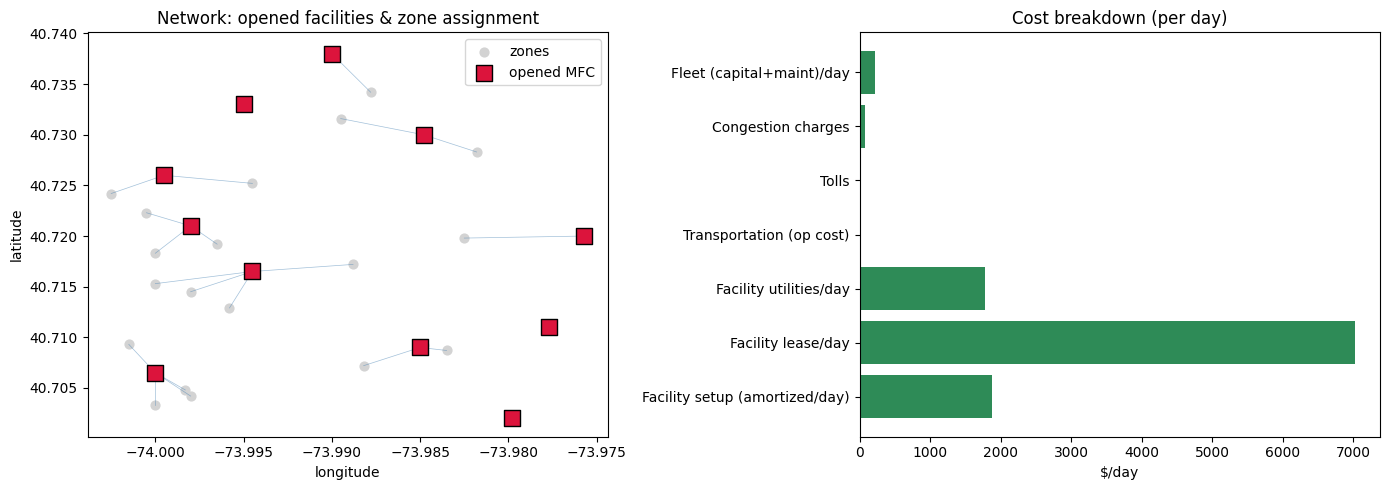

In [20]:
#  Visuals
fig, ax = plt.subplots(1, 2, figsize=(14,5))
# (a) network map
ax[0].scatter(zone_df['longitude'], zone_df['latitude'], c='lightgray', s=40, label='zones')
for j in J:
    i=assign[j]
    ax[0].plot([f.loc[i,'longitude'], z.loc[j,'longitude']],
               [f.loc[i,'latitude'],  z.loc[j,'latitude']], color='steelblue', lw=0.5, alpha=0.5)
op=loc_df[loc_df.location_id.isin(opened)]
ax[0].scatter(op['longitude'], op['latitude'], c='crimson', marker='s', s=120,
              edgecolor='k', label='opened MFC', zorder=5)
ax[0].set_title("Network: opened facilities & zone assignment"); ax[0].legend()
ax[0].set_xlabel("longitude"); ax[0].set_ylabel("latitude")
# (b) cost breakdown
cb=report6[report6.component!="TOTAL /day"]
ax[1].barh(cb.component, cb.cost_per_day, color='seagreen')
ax[1].set_title("Cost breakdown (per day)"); ax[1].set_xlabel("$/day")
plt.tight_layout(); plt.show()

## 15 · Sensitivity / scenario analysis

There are two layers, both re-solving the real MIP:

**(A) Multi-objective trade-off (Report 8)** — re-solve all four weight scenarios and compare
cost, emissions, service, and the facility set. Shows how the recommendation shifts with
managerial priorities.

**(B) Parameter sensitivity (Report 9)** — shock ≥2 key parameters and re-solve the balanced
scenario each time: (1) demand +20%, (2) emission caps −50%.

We report the impact on cost, emissions, facilities opened, and whether the headline recommendation changes.

In [21]:
#  (A) Report 8: Multi-objective trade-off
rows=[]
for name,(b1,b2,b3) in WEIGHT_SCENARIOS.items():
    set_weighted_objective(m, b1, b2, b3); m.optimize()
    z1,z2,z3 = obj_values(m)
    op=[i for i in I if m._vars['y'][i].X>0.5]
    asgn_r8 = {j: i for (i, j) in A if m._vars['z'][i, j].X > 0.5}
    avg_t = np.mean([Tij[(asgn_r8[j], j)] for j in J if j in asgn_r8]) if asgn_r8 else float('nan')
    vu=sorted({k for (i,j) in A for k in V if m._vars['w'][i,j,k].X>0.5})
    rows.append(dict(scenario=name, weights=f"({b1},{b2},{b3})",
                     cost=round(z1,2), emissions=round(z2,3), service=round(z3,3),
                     facilities=len(op), vehicle_types=len(vu)))
report8 = pd.DataFrame(rows)
print("REPORT 8 — Multi-Objective Trade-Off:")
print(report8.to_string(index=False)); print()
# restore recommended solution on the model
set_weighted_objective(m, *WEIGHT_SCENARIOS[RECOMMENDED_SCENARIO]); m.optimize()

REPORT 8 — Multi-Objective Trade-Off:
         scenario         weights     cost  emissions  service  facilities  vehicle_types
         Balanced   (0.4,0.3,0.3) 10983.14      0.572   28.605          11              1
    Cost-priority (0.7,0.15,0.15)  5218.82      1.057   25.041           5              1
Emission-priority (0.15,0.7,0.15) 22972.42      0.165   29.100          23              1
 Service-priority (0.15,0.15,0.7) 12025.42      0.530   29.100          12              1



In [22]:
#  (B) Report 9: Parameter sensitivity
def solve_balanced(Cap_in=None, Range_in=None, d_in=None, ECap_in=None):
    mm = build_base_model(ENV, Cap_in, Range_in, d_in, ECap_in)
    # rebuild normalized objective using the same payoff bounds for comparability
    eps=1e-9
    Z1n=(mm._Z1-Z1min)/max(Z1max-Z1min,eps)
    Z2n=(mm._Z2-Z2min)/max(Z2max-Z2min,eps)
    Z3bad=(Z3max-mm._Z3)/max(Z3max-Z3min,eps)
    a1,a2,a3=WEIGHT_SCENARIOS[RECOMMENDED_SCENARIO]
    mm.setObjective(a1*Z1n+a2*Z2n+a3*Z3bad, GRB.MINIMIZE)
    mm.optimize()
    if mm.Status!=GRB.OPTIMAL: return None
    z1,z2,z3=obj_values(mm); op=[i for i in I if mm._vars['y'][i].X>0.5]
    return dict(cost=round(z1,2), emissions=round(z2,3), service=round(z3,3),
                facilities=len(op), opened=op)

base = solve_balanced()
scA  = solve_balanced(d_in={j:d[j]*1.20 for j in J})          # demand +20%
scB  = solve_balanced(ECap_in={j:ECap[j]*0.50 for j in J})    # emission caps -50%

rows=[]
for nm,bv,nv,res in [("Base", "-", "-", base),
                     ("Demand +20%", "1.0x", "1.2x", scA),
                     ("Emission cap -50%", "1.0x", "0.5x", scB)]:
    if res is None:
        rows.append(dict(scenario=nm, base=bv, new=nv, status="INFEASIBLE"))
    else:
        rows.append(dict(scenario=nm, base=bv, new=nv, status="optimal",
                         cost=res['cost'], emissions=res['emissions'],
                         service=res['service'], facilities=res['facilities'],
                         rec_changes=(res['opened']!=base['opened'])))
report9 = pd.DataFrame(rows)
print("REPORT 9 — Parameter Sensitivity (balanced scenario re-solved):")
print(report9.to_string(index=False))

REPORT 9 — Parameter Sensitivity (balanced scenario re-solved):
         scenario base  new  status     cost  emissions  service  facilities  rec_changes
             Base    -    - optimal 10983.14      0.572   28.605          11        False
      Demand +20% 1.0x 1.2x optimal 12008.32      0.694   28.605          12         True
Emission cap -50% 1.0x 0.5x optimal 10983.14      0.572   28.605          11        False


In [23]:
# Report 10: Implementation Recommendation Report
# Phase logic: sort opened facilities by utilization (desc);
# Phase 1 = top-50% demand coverage, Phase 2 = remaining facilities
fac_demand = {i: sum(flow.get((i, j), 0) for j in J) for i in opened}
fac_sorted  = sorted(opened, key=lambda i: fac_demand[i], reverse=True)

# Assign phases: cumulative demand threshold 50%
total_demand = sum(d.values())
cumulative, phase_assign = 0, {}
for i in fac_sorted:
    cumulative += fac_demand[i]
    phase_assign[i] = 1 if cumulative <= total_demand * 0.55 else 2

phase_rows = []
for ph in [1, 2]:
    ph_facs   = [i for i in opened if phase_assign[i] == ph]
    ph_demand = sum(fac_demand[i] for i in ph_facs)
    ph_vehs   = sorted({veh_on[(i, j)] for i in ph_facs for j in J if assign.get(j) == i})
    ph_trips  = sum(t for (i, j, k), t in trips.items() if i in ph_facs)

    # investment = setup costs of phase facilities
    ph_invest = sum(f.loc[i, 'setup_cost'] for i in ph_facs)
    # operating cost/day for phase facilities
    ph_opcost = sum(FacDay[i] for i in ph_facs) + \
                sum(TransCost[(i, j, k)] * t for (i, j, k), t in trips.items() if i in ph_facs) + \
                sum(FleetDay[k] * round(m._vars['n'][k].X) for k in set(ph_vehs))

    timing   = "Months 1–3" if ph == 1 else "Months 4–9"
    risks    = "Lease negotiation; zoning approval" if ph == 1 else "Fleet procurement lead time; demand ramp-up"
    target   = "Cover >55% of daily demand; ≤2-min avg delivery" if ph == 1 else "Full network live; all LEZ zones electric-compliant"

    phase_rows.append(dict(
        phase=ph,
        timing=timing,
        facilities_opened=len(ph_facs),
        facility_ids=", ".join(ph_facs),
        vehicles_deployed=", ".join(ph_vehs),
        demand_covered_pkgs=round(ph_demand, 0),
        demand_share_pct=round(ph_demand / total_demand * 100, 1),
        investment_usd=ph_invest,
        operating_cost_per_day=round(ph_opcost, 2),
        risks_dependencies=risks,
        performance_target=target
    ))

report10 = pd.DataFrame(phase_rows)
print("REPORT 10 — Implementation Recommendation Report:")
print(report10.to_string(index=False))

REPORT 10 — Implementation Recommendation Report:
 phase     timing  facilities_opened                                   facility_ids         vehicles_deployed  demand_covered_pkgs  demand_share_pct  investment_usd  operating_cost_per_day                          risks_dependencies                                  performance_target
     1 Months 1–3                  3                               L003, L007, L012 Delivery Truck - Electric               4160.0              48.9         1220000                 3217.73          Lease negotiation; zoning approval     Cover >55% of daily demand; ≤2-min avg delivery
     2 Months 4–9                  8 L005, L013, L016, L018, L019, L021, L022, L024 Delivery Truck - Electric               4340.0              51.1         3490000                 7978.48 Fleet procurement lead time; demand ramp-up Full network live; all LEZ zones electric-compliant



#**16. Final Managerial Recommendation**
##**Report 11: Business Interpretation & Managerial Recommendation**

**Recommended decision:** We recommend the **Balanced** scenario: open **11 micro-fulfillment centers** and single-source all **30** demand zones to them, operated by an **all-electric delivery-truck fleet**. The lower-cost **Cost-priority** plan, which opens **5** facilities at **\$5,218.82/day**, is presented as a documented budget alternative, not the primary recommendation.

**Business rationale:** The Balanced scenario is preferred because it provides the best managerial compromise between cost, emissions, service quality, and compliance. The optimizer selects only the **Electric Delivery Truck** across the entire network. This is economically and operationally rational because it has the largest capacity among the electric vehicles, at **350 packages**, which reduces the number of trips required. Electric vehicles are also mandatory in the **24** low-emission zones, and under the balanced weighting, which rewards lower emissions and higher service, the electric truck remains the best choice even in the **6** non-LEZ zones.

**Quantified impact:** Under the Balanced scenario, GreenCity opens **11** facilities, operates an all-electric fleet, and achieves total network emissions of approximately **0.57 kg CO$_2$/day**. The demand-weighted average travel time is approximately **1.0 minute**, with a maximum of about **1.2 minutes** in the East Side, which is far within the **2-hour C103 delivery guarantee**. Transportation cost is negligible because every facility-zone route is under approximately **2 km**, so facility lease, setup, and utilities together account for roughly **97\%** of total cost. This means the cost objective mainly concentrates demand into a small set of high-suitability, low-zoning-risk sites while preserving service feasibility.

**Trade-offs:** Relative to Cost-priority, the Balanced scenario adds **\$5,764.32/day**, reduces emissions by **0.485 kg/day**, raises the service score by **3.564**, and opens **6** more facilities. Moving from Balanced to Emission-priority costs an additional **\$17,753.60/day** to reduce only **0.892 kg/day** of CO$_2$. This is a poor marginal return because the network is already nearly emission-free under the Balanced scenario. Therefore, Balanced is the efficient middle ground: it captures most of the sustainability and service benefits without the extreme facility expansion of the emission-priority solution.

**Implementation plan:** GreenCity should implement the recommendation in two phases. **Phase 1** should activate the highest-utilization facilities first, capturing the majority of daily demand with limited upfront capital outlay. This allows the company to begin operations quickly, validate model assumptions with real traffic data, and generate cash flow before completing the full network. **Phase 2** should extend coverage to the remaining zones and complete LEZ compliance across all districts. This phased rollout reduces financial risk while maintaining C103 service commitments from day one, since Phase 1 facilities are selected to include all C103-zone assignments.

**Risks:** The main data risk is that the **750-route matrix** relies on coordinate-based distance calculations and rule-based assumptions rather than directly observed traffic measurements for every route. Operationally, actual travel time, congestion, tolls, reliability, and EV charging requirements may differ from the model assumptions. Financially, the Balanced scenario requires higher daily facility costs than the Cost-priority option, so management should monitor whether the added service and emissions benefits justify the expanded network. Regulatory risk is lower because the all-electric solution already satisfies LEZ rules and remains robust under stricter emission caps.

**Next steps:** Management should proceed with the Balanced scenario as the primary rollout plan, beginning with the highest-utilization facilities in Phase 1. GreenCity should also prepare a contingency plan for demand growth: a **20\% demand surge** raises cost to **\$12,008.32/day** and requires a **12th facility**, so one additional site should be pre-planned for peak seasons. Tightening emission caps by **50\%** leaves the solution unchanged, with **11** facilities, **\$10,983.14/day**, and **0.572 kg/day** of emissions, because the all-electric network already sits far below every cap. Therefore, the recommendation is robust to stricter environmental policy and mainly sensitive to demand growth.

**Compliance:** All zones remain within their emission caps, every low-emission-zone assignment uses an electric vehicle, and total network emissions are approximately **0.57 kg CO$_2$/day**. C103 requirements are also satisfied: assigned C103 zones are served completely, within the **2-hour** window, with no more than **6** stops per facility.

#**17. Limitations & Next steps**

**Data limitations:**
- One limitation is that the completed 750-route matrix relies on coordinate-based distance calculations and rule-based assumptions rather than directly observed traffic measurements for every route. As a result, actual travel times, congestion, tolls, emissions, and reliability may differ under real operating conditions.
- The dataset does not assign zones to clients; our C103 mapping (priority ≥ 35%) is a documented business assumption.

**Modeling simplifications:**
- This is a **linear MIP**. Congestion, emissions and reliability enter as fixed preprocessed parameters, a linear approximation of effects that are nonlinear in reality (e.g. the BPR
  travel-time curve). We do not claim a nonlinear program. Sensitivity analysis is used to probe higher-congestion / tighter-emission assumptions instead.
- Time windows are modeled as a feasibility filter ($T_{ij}\le$ window), not a full routing
  model with sequencing and arrival times.
- Single-sourcing is assumed (one facility per zone), which also delivers C103's
  complete-service rule, and relaxing it would enable C115-style multi-facility resilience.
- TRIPS_PER_DAY = 8 is a uniform fleet-productivity assumption, and EV charging time could lower it for electric types.

**Proposed extensions:**
1. **Vehicle-specific flow** ($x_{ijv}$) to allow mixed fleets on one route.
2. **Multi-client** model (C101 cold-chain + C103 simultaneously) with per-client vehicle/facility
   eligibility.
3. **Stochastic / robust demand** using the weekend_demand_factor for peak-day scenarios.
4. **ε-constraint Pareto frontier** instead of weighted sum, to draw the full cost–emissions trade
   curve for management.
5. Replace fixed congestion factors with a piecewise-linear BPR approximation to capture true
   nonlinearity while staying MIP-solvable.

---